


# TEAM'S CODE




In [ ]:
!pip install kagglehub pyspark==3.5.1



In [ ]:
import kagglehub
import os

path = kagglehub.dataset_download("ealaxi/paysim1")
print("Dataset Path:", path)

Using Colab cache for faster access to the 'paysim1' dataset.
Dataset Path: /kaggle/input/paysim1


In [ ]:
import os
from pyspark.sql import SparkSession

# Install Java 8 (if not already installed) to ensure compatibility
!apt-get install openjdk-8-jdk-headless -qq > /dev/null

os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"

spark = SparkSession.builder \
    .appName("FraudDetection") \
    .master("local[*]") \
    .config("spark.driver.host", "127.0.0.1") \
    .getOrCreate()

In [ ]:
file = [f for f in os.listdir(path) if f.endswith(".csv")][0]
file_path = os.path.join(path, file)

df = spark.read.csv(file_path, header=True, inferSchema=True)

df.show(5)
df.printSchema()

+----+--------+--------+-----------+-------------+--------------+-----------+--------------+--------------+-------+--------------+
|step|    type|  amount|   nameOrig|oldbalanceOrg|newbalanceOrig|   nameDest|oldbalanceDest|newbalanceDest|isFraud|isFlaggedFraud|
+----+--------+--------+-----------+-------------+--------------+-----------+--------------+--------------+-------+--------------+
|   1| PAYMENT| 9839.64|C1231006815|     170136.0|     160296.36|M1979787155|           0.0|           0.0|      0|             0|
|   1| PAYMENT| 1864.28|C1666544295|      21249.0|      19384.72|M2044282225|           0.0|           0.0|      0|             0|
|   1|TRANSFER|   181.0|C1305486145|        181.0|           0.0| C553264065|           0.0|           0.0|      1|             0|
|   1|CASH_OUT|   181.0| C840083671|        181.0|           0.0|  C38997010|       21182.0|           0.0|      1|             0|
|   1| PAYMENT|11668.14|C2048537720|      41554.0|      29885.86|M1230701703|      

In [ ]:
print("Number of Rows:", df.count())
print("Number of Columns:", len(df.columns))

Number of Rows: 6362620
Number of Columns: 11


In [ ]:
from pyspark.sql import functions as F

# توزيع الفراود
df.groupBy("isFraud").count().show()

# توزيع الأنواع
df.groupBy("type").agg(
    F.count("*").alias("Total_Transactions"),
    F.sum("isFraud").alias("Total_Fraud")
).show()

+-------+-------+
|isFraud|  count|
+-------+-------+
|      1|   8213|
|      0|6354407|
+-------+-------+

+--------+------------------+-----------+
|    type|Total_Transactions|Total_Fraud|
+--------+------------------+-----------+
|TRANSFER|            532909|       4097|
| CASH_IN|           1399284|          0|
|CASH_OUT|           2237500|       4116|
| PAYMENT|           2151495|          0|
|   DEBIT|             41432|          0|
+--------+------------------+-----------+



In [ ]:
df = df.dropna()
df = df.dropDuplicates()

# حذف الأعمدة غير المهمة
df = df.drop("nameOrig", "nameDest")

In [ ]:
from pyspark.sql.functions import col, when, avg

df = df.withColumn("balanceOrig_diff", col("oldbalanceOrg") - col("newbalanceOrig"))
df = df.withColumn("balanceDest_diff", col("newbalanceDest") - col("oldbalanceDest"))

df = df.withColumn("is_zero_balance",
                   when(col("newbalanceOrig") == 0, 1).otherwise(0))

mean_amount = df.select(avg("amount")).first()[0]

df = df.withColumn("is_large_amount",
                   when(col("amount") > mean_amount, 1).otherwise(0))

In [ ]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder

indexer = StringIndexer(inputCol="type", outputCol="type_index")
df = indexer.fit(df).transform(df)

encoder = OneHotEncoder(inputCols=["type_index"], outputCols=["type_encoded"])
df = encoder.fit(df).transform(df)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ناخد عينة ذكية
fraud_df = df.filter(col("isFraud") == 1).toPandas()
non_fraud_sample = df.filter(col("isFraud") == 0) \
                     .sample(False, 0.01, seed=42) \
                     .limit(30000) \
                     .toPandas()

sample_df = pd.concat([fraud_df, non_fraud_sample])

sns.set_theme(style="whitegrid")

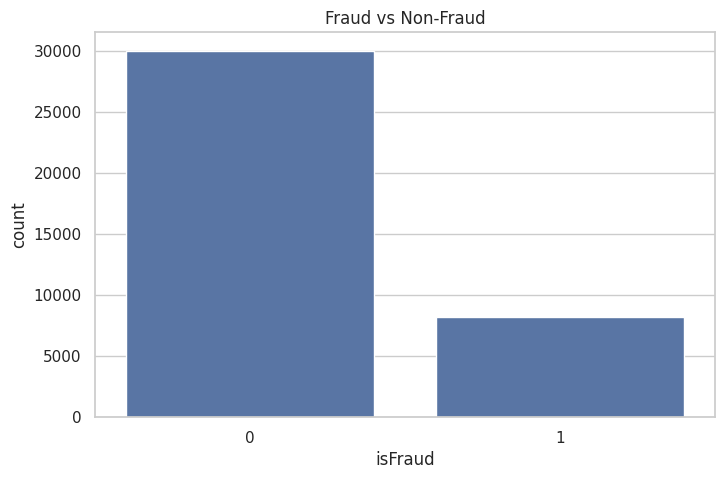

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x="isFraud", data=sample_df)
plt.title("Fraud vs Non-Fraud")
plt.show()

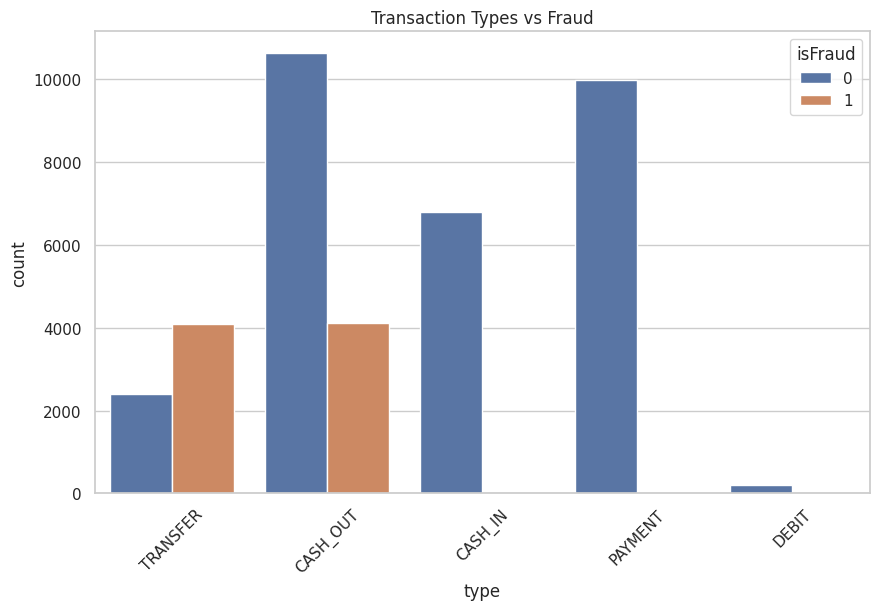

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(x="type", hue="isFraud", data=sample_df)
plt.xticks(rotation=45)
plt.title("Transaction Types vs Fraud")
plt.show()

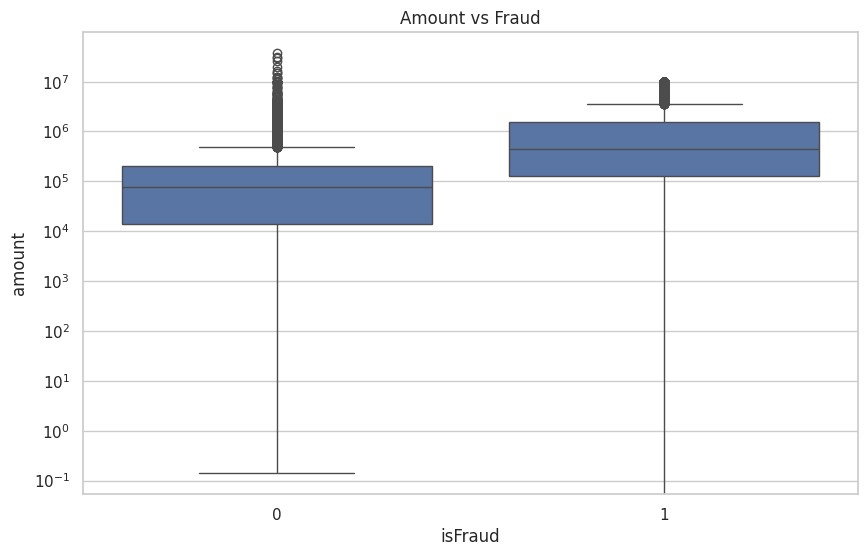

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(x="isFraud", y="amount", data=sample_df)
plt.yscale('log')
plt.title("Amount vs Fraud")
plt.show()

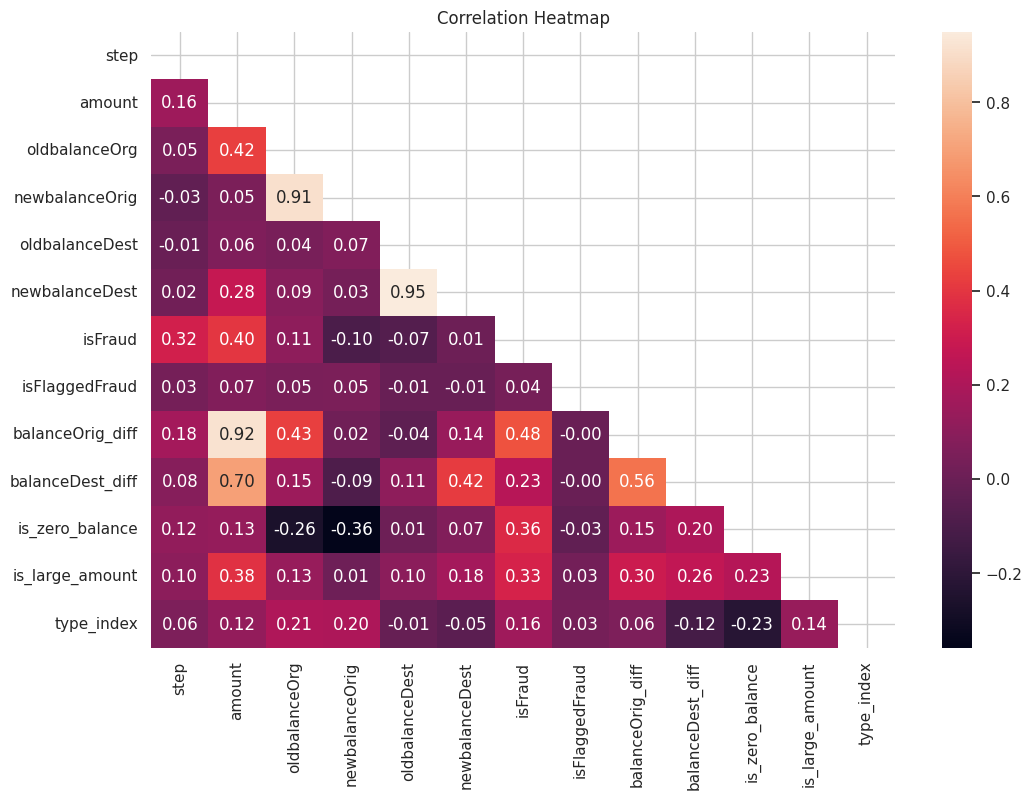

In [ ]:
plt.figure(figsize=(12,8))

numeric_cols = sample_df.select_dtypes(include=[np.number]).columns
corr = sample_df[numeric_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

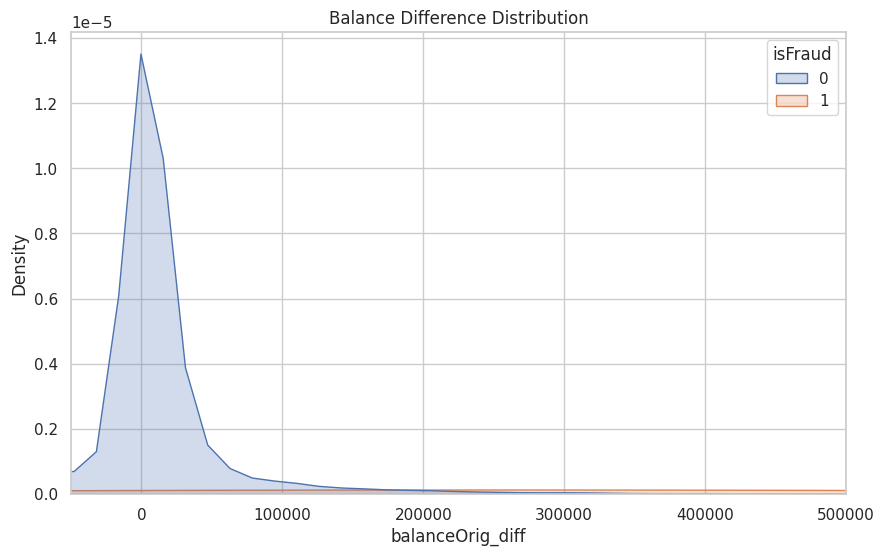

In [ ]:
plt.figure(figsize=(10,6))
sns.kdeplot(data=sample_df, x="balanceOrig_diff", hue="isFraud", fill=True)
plt.xlim(-50000, 500000)
plt.title("Balance Difference Distribution")
plt.show()

# MODELING

In [ ]:
from pyspark.ml.feature import VectorAssembler

feature_cols = [
    "amount", "oldbalanceOrg", "newbalanceOrig",
    "oldbalanceDest", "newbalanceDest",
    "balanceOrig_diff", "balanceDest_diff",
    "is_zero_balance", "is_large_amount"
]

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
df_model = assembler.transform(df)

df_model.select("features", "isFraud").show(5)

+--------------------+-------+
|            features|isFraud|
+--------------------+-------+
|[210370.09,0.0,0....|      0|
|(9,[0,3,6,7],[899...|      0|
|[418688.27,188809...|      0|
|[127954.7,373873....|      0|
|(9,[0,1,5,7],[779...|      0|
+--------------------+-------+
only showing top 5 rows



In [ ]:
#CLASS WEIGHT
from pyspark.sql.functions import col, when

# حساب النسبة بين الكلاسات
fraud_count = df_model.filter(col("isFraud") == 1).count()
non_fraud_count = df_model.filter(col("isFraud") == 0).count()

ratio = non_fraud_count / fraud_count

print("Class Ratio:", ratio)

# إضافة weight
df_model = df_model.withColumn(
    "classWeight",
    when(col("isFraud") == 1, ratio).otherwise(1.0)
)

Class Ratio: 773.7010836478753


In [ ]:
#SPLIT
trainDF, testDF = df_model.randomSplit([0.8, 0.2], seed=42)

print(trainDF.count(), testDF.count())

5089679 1272941


In [ ]:
from pyspark.ml.classification import DecisionTreeClassifier
dt = DecisionTreeClassifier(
    featuresCol="features",
    labelCol="isFraud",
    predictionCol="prediction",
    maxDepth=10,
    weightCol="classWeight"
)

dt_model = dt.fit(trainDF)
pred_dt = dt_model.transform(testDF)

pred_dt.select("isFraud", "prediction", "probability").show(5)

+-------+----------+--------------------+
|isFraud|prediction|         probability|
+-------+----------+--------------------+
|      0|       0.0|           [1.0,0.0]|
|      0|       0.0|[0.99537284658369...|
|      0|       0.0|           [1.0,0.0]|
|      0|       0.0|           [1.0,0.0]|
|      0|       0.0|           [1.0,0.0]|
+-------+----------+--------------------+
only showing top 5 rows



In [ ]:
auc_dt = evaluator_auc.evaluate(pred_dt)
print("Decision Tree AUC:", auc_dt)

In [ ]:
acc_dt = evaluator_acc.evaluate(pred_dt)
f1_dt = f1_eval.evaluate(pred_dt)

print("DT Accuracy:", acc_dt)
print("DT F1:", f1_dt)

In [ ]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "Decision Tree"],
    "Accuracy": [acc_lr, acc_rf, acc_dt],
    "F1 Score": [f1_lr, f1_rf, f1_dt],
    "AUC": [auc_lr, auc_rf, auc_dt]
})

results

In [ ]:
pred_dt.groupBy("isFraud", "prediction").count().show()

+-------+----------+-------+
|isFraud|prediction|  count|
+-------+----------+-------+
|      1|       0.0|     16|
|      0|       0.0|1245738|
|      1|       1.0|   1613|
|      0|       1.0|  25574|
+-------+----------+-------+



In [ ]:
from pyspark.ml.classification import LogisticRegression
lr = LogisticRegression(
    featuresCol="features",
    labelCol="isFraud",
    weightCol="classWeight",   # 0000
    predictionCol="prediction"
)

lr.setThreshold(0.3)   #
lr_model = lr.fit(trainDF)

pred_lr = lr_model.transform(testDF)

pred_lr.select("isFraud", "prediction", "probability").show(5)

+-------+----------+--------------------+
|isFraud|prediction|         probability|
+-------+----------+--------------------+
|      0|       0.0|[0.99975930754104...|
|      0|       0.0|           [1.0,0.0]|
|      0|       0.0|[0.99995550109981...|
|      0|       0.0|[0.99994111452138...|
|      0|       0.0|[0.99968617639153...|
+-------+----------+--------------------+
only showing top 5 rows



In [ ]:
from pyspark.ml import Pipeline

pipeline = Pipeline(stages=[lr])
pipeline_model = pipeline.fit(trainDF)

pipeline_model.write().overwrite().save("full_pipeline")

In [ ]:
from pyspark.ml.classification import RandomForestClassifier

rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="isFraud",
    predictionCol="prediction",
    numTrees=50
)

rf_model = rf.fit(trainDF)

pred_rf = rf_model.transform(testDF)

pred_rf.select("isFraud", "prediction").show(5)

+-------+----------+
|isFraud|prediction|
+-------+----------+
|      0|       0.0|
|      0|       0.0|
|      0|       0.0|
|      0|       0.0|
|      0|       0.0|
+-------+----------+
only showing top 5 rows



In [ ]:
from pyspark.ml import Pipeline

pipeline = Pipeline(stages=[lr])
pipeline_model = pipeline.fit(trainDF)

pipeline_model.write().overwrite().save("full_pipeline")

In [ ]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator

evaluator_auc = BinaryClassificationEvaluator(
    labelCol="isFraud",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)

auc_lr = evaluator_auc.evaluate(pred_lr)
auc_rf = evaluator_auc.evaluate(pred_rf)

print("Logistic Regression AUC:", auc_lr)
print("Random Forest AUC:", auc_rf)

In [ ]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

evaluator_acc = MulticlassClassificationEvaluator(
    labelCol="isFraud",
    predictionCol="prediction",
    metricName="accuracy"
)

acc_lr = evaluator_acc.evaluate(pred_lr)
acc_rf = evaluator_acc.evaluate(pred_rf)

print("LR Accuracy:", acc_lr)
print("RF Accuracy:", acc_rf)

In [ ]:
pred_lr.groupBy("isFraud", "prediction").count().show()

pred_rf.groupBy("isFraud", "prediction").count().show()

In [ ]:
pred_lr.groupBy("isFraud", "prediction").count().show()

pred_rf.groupBy("isFraud", "prediction").count().show()

In [ ]:
f1_eval = MulticlassClassificationEvaluator(
    labelCol="isFraud",
    predictionCol="prediction",
    metricName="f1"
)

f1_lr = f1_eval.evaluate(pred_lr)
f1_rf = f1_eval.evaluate(pred_rf)


In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [acc_lr, acc_rf],
    "F1 Score": [f1_lr, f1_rf],
    "AUC": [auc_lr, auc_rf]
})

results

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.barplot(x="Model", y="Accuracy", data=results)
plt.title("Model Accuracy Comparison")
plt.show()

In [ ]:
results.set_index("Model")[["AUC", "F1 Score"]].plot(kind="bar")

Logistic Regression was selected as the final model due to its higher AUC and better fraud detection capability (lower false negatives).

Although Random Forest achieved higher accuracy, Logistic Regression performed better in detecting fraudulent transactions, as indicated by higher AUC and lower false negatives. Therefore, it was selected as the final model.

# MODELING 2

In [ ]:
# LightGBM

fraud_df = df_model.filter(col("isFraud") == 1)

nonfraud_df = df_model.filter(col("isFraud") == 0).sample(False, 0.05, seed=42)

balanced_df = fraud_df.union(nonfraud_df)

pdf = balanced_df.select("features", "isFraud").toPandas()



In [ ]:
from sklearn.model_selection import train_test_split

X = np.array(list(pdf["features"].apply(lambda x: x.toArray())))
y = pdf["isFraud"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
from lightgbm import LGBMClassifier


lgbm = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    class_weight="balanced",
    random_state=42
)

lgbm.fit(X_train, y_train)
y_pred = lgbm.predict(X_test)
y_prob = lgbm.predict_proba(X_test)[:, 1]

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

auc = roc_auc_score(y_test, y_prob)
print("AUC:", auc)

print(classification_report(y_test, y_pred))

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d")
plt.title("LightGBM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (LightGBM)")
plt.show()

In [ ]:
# XGBoost

from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    eval_metric="logloss",
    random_state=42
)

xgb.fit(X_train, y_train)

In [ ]:
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

auc_xgb = roc_auc_score(y_test, y_prob_xgb)
print("XGBoost AUC:", auc_xgb)

print(classification_report(y_test, y_pred_xgb))

In [ ]:
cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d")
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_prob_xgb)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("XGBoost Precision-Recall Curve")
plt.show()

#report

Due to class imbalance, accuracy was not considered a reliable metric, so AUC and F1-score were used instead.

The model was evaluated based on its ability to minimize false negatives, as missing a fraud case is more critical.

In fraud detection, identifying fraudulent transactions is more important than avoiding false alarms, therefore the model with better recall was selected.

The final model was selected based on its ability to detect fraud cases effectively while handling class imbalance, ensuring better real-world applicability.

In [ ]:
import pickle

pickle.dump(model, open("model/trained_model.pkl", "wb"))

# Streamlit App

In [ ]:
!pip -q install streamlit scikit-learn pandas numpy

In [ ]:
%%writefile /content/app.py
import io
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import streamlit as st
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


st.set_page_config(
    page_title="Fraud Detection App",
    layout="wide",
)


REQUIRED_COLUMNS = [
    "type",
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
]

TARGET_COLUMN = "isFraud"

NUMERIC_FEATURES = [
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "balanceOrig_diff",
    "balanceDest_diff",
    "is_zero_balance",
    "is_large_amount",
]

CATEGORICAL_FEATURES = ["type"]


@st.cache_data(show_spinner=False)
def demo_dataset() -> pd.DataFrame:
    rng = np.random.default_rng(42)
    rows = 1200
    transaction_types = np.array(["CASH_OUT", "TRANSFER", "PAYMENT", "CASH_IN", "DEBIT"])
    types = rng.choice(transaction_types, rows, p=[0.35, 0.18, 0.28, 0.15, 0.04])
    amount = rng.lognormal(mean=10.2, sigma=1.0, size=rows).round(2)
    old_org = rng.lognormal(mean=11.0, sigma=1.2, size=rows).round(2)
    suspicious = ((types == "TRANSFER") | (types == "CASH_OUT")) & (amount > np.quantile(amount, 0.82))
    new_org = np.maximum(old_org - amount * rng.uniform(0.75, 1.05, rows), 0).round(2)
    old_dest = rng.lognormal(mean=10.8, sigma=1.0, size=rows).round(2)
    new_dest = (old_dest + amount * rng.uniform(0.65, 1.2, rows)).round(2)
    fraud_probability = np.where(suspicious & (new_org == 0), 0.65, 0.015)
    is_fraud = rng.binomial(1, fraud_probability)

    return pd.DataFrame(
        {
            "type": types,
            "amount": amount,
            "oldbalanceOrg": old_org,
            "newbalanceOrig": new_org,
            "oldbalanceDest": old_dest,
            "newbalanceDest": new_dest,
            "isFraud": is_fraud,
        }
    )


def add_features(df: pd.DataFrame) -> pd.DataFrame:
    prepared = df.copy()
    for column in REQUIRED_COLUMNS:
        if column != "type":
            prepared[column] = pd.to_numeric(prepared[column], errors="coerce")

    mean_amount = prepared["amount"].mean()
    prepared["balanceOrig_diff"] = prepared["oldbalanceOrg"] - prepared["newbalanceOrig"]
    prepared["balanceDest_diff"] = prepared["newbalanceDest"] - prepared["oldbalanceDest"]
    prepared["is_zero_balance"] = (prepared["newbalanceOrig"] == 0).astype(int)
    prepared["is_large_amount"] = (prepared["amount"] > mean_amount).astype(int)
    prepared["type"] = prepared["type"].astype(str)
    return prepared


def validate_dataset(df: pd.DataFrame, needs_target: bool = True) -> List[str]:
    required = REQUIRED_COLUMNS + ([TARGET_COLUMN] if needs_target else [])
    return [column for column in required if column not in df.columns]


def build_preprocessor() -> ColumnTransformer:
    numeric_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )
    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore")),
        ]
    )
    return ColumnTransformer(
        transformers=[
            ("num", numeric_pipeline, NUMERIC_FEATURES),
            ("cat", categorical_pipeline, CATEGORICAL_FEATURES),
        ]
    )


def model_catalog() -> Dict[str, object]:
    return {
        "Logistic Regression": LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42,
        ),
        "Random Forest": RandomForestClassifier(
            n_estimators=160,
            max_depth=12,
            min_samples_leaf=2,
            class_weight="balanced_subsample",
            random_state=42,
            n_jobs=-1,
        ),
        "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    }


@st.cache_data(show_spinner=False)
def csv_bytes_to_df(file_bytes: bytes) -> pd.DataFrame:
    return pd.read_csv(io.BytesIO(file_bytes))


@st.cache_resource(show_spinner=False)
def train_models(dataset: pd.DataFrame) -> Tuple[Dict[str, Pipeline], pd.DataFrame]:
    prepared = add_features(dataset).dropna(subset=[TARGET_COLUMN])
    prepared[TARGET_COLUMN] = pd.to_numeric(prepared[TARGET_COLUMN], errors="coerce")
    prepared = prepared.dropna(subset=[TARGET_COLUMN])
    prepared[TARGET_COLUMN] = prepared[TARGET_COLUMN].astype(int)

    if prepared[TARGET_COLUMN].nunique() < 2:
        raise ValueError("The target column must contain both fraud and non-fraud examples.")

    x = prepared[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
    y = prepared[TARGET_COLUMN]

    stratify = y if y.value_counts().min() >= 2 else None
    x_train, x_test, y_train, y_test = train_test_split(
        x,
        y,
        test_size=0.2,
        random_state=42,
        stratify=stratify,
    )

    trained_models: Dict[str, Pipeline] = {}
    rows = []

    for name, estimator in model_catalog().items():
        pipeline = Pipeline(
            steps=[
                ("preprocessor", build_preprocessor()),
                ("model", estimator),
            ]
        )
        pipeline.fit(x_train, y_train)
        prediction = pipeline.predict(x_test)

        if hasattr(pipeline, "predict_proba"):
            probability = pipeline.predict_proba(x_test)[:, 1]
        else:
            probability = prediction

        try:
            auc = roc_auc_score(y_test, probability)
        except ValueError:
            auc = np.nan

        rows.append(
            {
                "Model": name,
                "Accuracy": accuracy_score(y_test, prediction),
                "Precision": precision_score(y_test, prediction, zero_division=0),
                "Recall": recall_score(y_test, prediction, zero_division=0),
                "F1 Score": f1_score(y_test, prediction, zero_division=0),
                "AUC": auc,
            }
        )
        trained_models[name] = pipeline

    results = pd.DataFrame(rows).sort_values(["AUC", "F1 Score"], ascending=False)
    return trained_models, results


def predict_one(model: Pipeline, values: Dict[str, object]) -> Tuple[int, float]:
    input_df = pd.DataFrame([values])
    prepared = add_features(input_df)
    features = prepared[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
    prediction = int(model.predict(features)[0])
    probability = float(model.predict_proba(features)[0][1])
    return prediction, probability


def predict_many(model: Pipeline, df: pd.DataFrame) -> pd.DataFrame:
    prepared = add_features(df)
    features = prepared[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
    output = df.copy()
    output["fraud_prediction"] = model.predict(features).astype(int)
    output["fraud_probability"] = model.predict_proba(features)[:, 1]
    return output


st.title("Fraud Detection Streamlit App")
st.caption("PaySim transaction fraud prediction with model comparison and model selection.")

with st.sidebar:
    st.header("Dataset")
    uploaded_dataset = st.file_uploader("Upload PaySim CSV", type=["csv"])
    use_demo = st.toggle("Use demo dataset", value=uploaded_dataset is None)
    st.divider()
    st.markdown("Required columns")
    st.code(", ".join(REQUIRED_COLUMNS + [TARGET_COLUMN]), language="text")

if uploaded_dataset is not None:
    dataset = csv_bytes_to_df(uploaded_dataset.getvalue())
    dataset_source = uploaded_dataset.name
elif use_demo:
    dataset = demo_dataset()
    dataset_source = "Built-in demo dataset"
else:
    st.info("Upload a dataset or enable the demo dataset to train the models.")
    st.stop()

missing_columns = validate_dataset(dataset)
if missing_columns:
    st.error(f"Missing required columns: {', '.join(missing_columns)}")
    st.stop()

with st.expander("Dataset preview", expanded=True):
    left, right, third = st.columns(3)
    left.metric("Source", dataset_source)
    right.metric("Rows", f"{len(dataset):,}")
    third.metric("Fraud rows", f"{int(pd.to_numeric(dataset[TARGET_COLUMN], errors='coerce').fillna(0).sum()):,}")
    st.dataframe(dataset.head(50), use_container_width=True)

with st.spinner("Training models and calculating metrics..."):
    try:
        models, results = train_models(dataset)
    except ValueError as exc:
        st.error(str(exc))
        st.stop()

st.subheader("Model Comparison")
metrics_view = results.copy()
for column in ["Accuracy", "Precision", "Recall", "F1 Score", "AUC"]:
    metrics_view[column] = metrics_view[column].map(lambda value: "" if pd.isna(value) else f"{value:.3f}")
st.dataframe(metrics_view, use_container_width=True, hide_index=True)

chart_data = results.set_index("Model")[["Accuracy", "Precision", "Recall", "F1 Score", "AUC"]]
st.bar_chart(chart_data)

best_model_name = results.iloc[0]["Model"]
selected_model_name = st.selectbox(
    "Choose model for prediction",
    list(models.keys()),
    index=list(models.keys()).index(best_model_name),
)
selected_model = models[selected_model_name]

st.subheader("Single Transaction Prediction")
col1, col2, col3 = st.columns(3)
with col1:
    transaction_type = st.selectbox("Transaction type", ["CASH_OUT", "TRANSFER", "PAYMENT", "CASH_IN", "DEBIT"])
    amount = st.number_input("Amount", min_value=0.0, value=150000.0, step=1000.0)
with col2:
    oldbalance_org = st.number_input("Old origin balance", min_value=0.0, value=150000.0, step=1000.0)
    newbalance_orig = st.number_input("New origin balance", min_value=0.0, value=0.0, step=1000.0)
with col3:
    oldbalance_dest = st.number_input("Old destination balance", min_value=0.0, value=0.0, step=1000.0)
    newbalance_dest = st.number_input("New destination balance", min_value=0.0, value=150000.0, step=1000.0)

if st.button("Predict Fraud", type="primary"):
    prediction, probability = predict_one(
        selected_model,
        {
            "type": transaction_type,
            "amount": amount,
            "oldbalanceOrg": oldbalance_org,
            "newbalanceOrig": newbalance_orig,
            "oldbalanceDest": oldbalance_dest,
            "newbalanceDest": newbalance_dest,
        },
    )
    if prediction == 1:
        st.error(f"Fraud predicted. Probability: {probability:.2%}")
    else:
        st.success(f"Not fraud predicted. Fraud probability: {probability:.2%}")

st.subheader("Batch Prediction")
prediction_file = st.file_uploader(
    "Upload transactions CSV for prediction",
    type=["csv"],
    key="prediction_file",
)

if prediction_file is not None:
    prediction_df = csv_bytes_to_df(prediction_file.getvalue())
    missing_prediction_columns = validate_dataset(prediction_df, needs_target=False)
    if missing_prediction_columns:
        st.error(f"Missing required prediction columns: {', '.join(missing_prediction_columns)}")
    else:
        predictions = predict_many(selected_model, prediction_df)
        st.dataframe(predictions.head(100), use_container_width=True)
        csv_output = predictions.to_csv(index=False).encode("utf-8")
        st.download_button(
            "Download predictions",
            data=csv_output,
            file_name="fraud_predictions.csv",
            mime="text/csv",
        )


In [ ]:
!pkill -f streamlit || true
!pkill -f cloudflared || true


In [ ]:
!streamlit run /content/app.py \
  --server.address 0.0.0.0 \
  --server.port 8501 \
  --server.maxUploadSize 1000 \
  > /content/streamlit.log 2>&1 &



In [ ]:
!/content/cloudflared tunnel --url http://localhost:8501


In [ ]:
from pyspark.sql.functions import col, when, avg
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

# STEP 1: SMART SAMPLING
fraud_df = df.filter(col("isFraud") == 1)
non_fraud_df = df.filter(col("isFraud") == 0) \
                 .sample(False, 0.01, seed=42) \
                 .limit(30000)

df_sample = fraud_df.union(non_fraud_df)

print("Sample Size:", df_sample.count())
print("Fraud in sample:", df_sample.filter(col("isFraud") == 1).count())
print("Normal in sample:", df_sample.filter(col("isFraud") == 0).count())

# STEP 2: FEATURE ENGINEERING
df_sample = df_sample.withColumn("balanceOrig_diff", col("oldbalanceOrg") - col("newbalanceOrig"))
df_sample = df_sample.withColumn("balanceDest_diff", col("newbalanceDest") - col("oldbalanceDest"))
df_sample = df_sample.withColumn("is_zero_balance", when(col("newbalanceOrig") == 0, 1).otherwise(0))

mean_amount = df_sample.select(avg("amount")).first()[0]
df_sample = df_sample.withColumn("is_large_amount", when(col("amount") > mean_amount, 1).otherwise(0))

# STEP 3: ENCODING
indexer = StringIndexer(inputCol="type", outputCol="type_index")
df_sample = indexer.fit(df_sample).transform(df_sample)

encoder = OneHotEncoder(inputCols=["type_index"], outputCols=["type_encoded"])
df_sample = encoder.fit(df_sample).transform(df_sample)

# STEP 4: VECTOR ASSEMBLER
feature_cols = [
    "amount", "oldbalanceOrg", "newbalanceOrig",
    "oldbalanceDest", "newbalanceDest",
    "balanceOrig_diff", "balanceDest_diff",
    "is_zero_balance", "is_large_amount"
]

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
df_model = assembler.transform(df_sample)

# STEP 5: IMBALANCED HANDLING - OVERSAMPLING
fraud_count = df_model.filter(col("isFraud") == 1).count()
non_fraud_count = df_model.filter(col("isFraud") == 0).count()
ratio = non_fraud_count / fraud_count

print(f"\nBefore Oversampling — Fraud: {fraud_count}, Normal: {non_fraud_count}")

fraud_oversampled = df_model.filter(col("isFraud") == 1) \
                             .sample(withReplacement=True, fraction=ratio, seed=42)

df_balanced = df_model.filter(col("isFraud") == 0).union(fraud_oversampled)

print(f"After Oversampling  — Fraud: {df_balanced.filter(col('isFraud')==1).count()}, "
      f"Normal: {df_balanced.filter(col('isFraud')==0).count()}")

# STEP 6: SPLIT
trainDF, testDF = df_balanced.randomSplit([0.8, 0.2], seed=42)
print(f"\nTrain: {trainDF.count()} | Test: {testDF.count()}")

# STEP 7: DECISION TREE MODEL
dt = DecisionTreeClassifier(
    featuresCol="features",
    labelCol="isFraud",
    predictionCol="prediction",
    maxDepth=10
)

dt_model = dt.fit(trainDF)
pred_dt = dt_model.transform(testDF)

pred_dt.select("isFraud", "prediction", "probability").show(5)

# STEP 8: EVALUATION
evaluator_auc = BinaryClassificationEvaluator(
    labelCol="isFraud",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)

evaluator_acc = MulticlassClassificationEvaluator(
    labelCol="isFraud",
    predictionCol="prediction",
    metricName="accuracy"
)

f1_eval = MulticlassClassificationEvaluator(
    labelCol="isFraud",
    predictionCol="prediction",
    metricName="f1"
)

auc_dt = evaluator_auc.evaluate(pred_dt)
acc_dt = evaluator_acc.evaluate(pred_dt)
f1_dt  = f1_eval.evaluate(pred_dt)

print("\n========== Decision Tree Results ==========")
print(f"AUC      : {auc_dt:.4f}")
print(f"Accuracy : {acc_dt:.4f}")
print(f"F1 Score : {f1_dt:.4f}")

# STEP 9: CONFUSION MATRIX
print("\nConfusion Matrix:")
pred_dt.groupBy("isFraud", "prediction").count().show()